Testing sigmaM emulation for hmf calculations

In [ ]:
from halox import hmf, emus, lss
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt

In [7]:
cosmo_fid = jc.Planck15()

cosmo_high_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.9,
    n_s=cosmo_fid.n_s,
    Omega_k=0, w0=-1, wa=0
)

cosmo_low_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.7,
    n_s=cosmo_fid.n_s,
    Omega_k=0, w0=-1, wa=0
)

jax.tree_util.tree_structure(cosmo_fid)

cmgs = [
    cosmo_fid,
    cosmo_high_s8,
    cosmo_low_s8,
]

cosmo_rays = emus.sigmaM.stack_cosmologies(cmgs)

Ms = jnp.logspace(11,16,256)
zs = jnp.array([0.0, 0.1, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0])

print(Ms.shape)

emu_mf_vmap = jax.vmap(jax.vmap(
    lambda M, z, cosmo: hmf.tinker08_mass_function_emu(
        M, z, cosmo,
        emu = emus.sigmaM.SigmaMEmulator("../src/halox/emus/sigma_40k_conv5.npz")
    ),
    in_axes=(None, None, 0)
), in_axes=(None, 0, None)
)

out3 = emu_mf_vmap(Ms, zs, cosmo_rays)


mf_vmap = jax.vmap(jax.vmap(
    lambda M, z, cosmo: hmf.tinker08_mass_function(
        M, z, cosmo, delta_c = 200, n_k_int = 5000
    ),
    in_axes=(None, None, 0)),
    in_axes=(None, 0, None)
)

out2 = mf_vmap(Ms, zs, cosmo_rays)

# emu_mf_vmap(
#     Ms, 
#     zs, 
#     cosmologies, 
#     weights_path = "/Users/lamoreau/halox/src/halox/emus/sigma_40k_conv2.npz"
#     )

(256,)


In [8]:
emu = emus.sigmaM.SigmaMEmulator("../src/halox/emus/sigma_40k_conv5.npz")
emu_sig = jax.vmap(jax.vmap(
    lambda M, z, cosmo: (emu(M, z, cosmo)),
    in_axes=(None, None, 0)
), in_axes=(None, 0, None)
)
nor_sig = jax.vmap(jax.vmap(
    lambda M, z, cosmo: (lss.sigma_M(M, z, cosmo)),
    in_axes=(None, None, 0)
), in_axes=(None, 0, None)
)

e_sig = emu_sig(Ms, zs, cosmo_rays)
n_sig = nor_sig(Ms, zs, cosmo_rays)

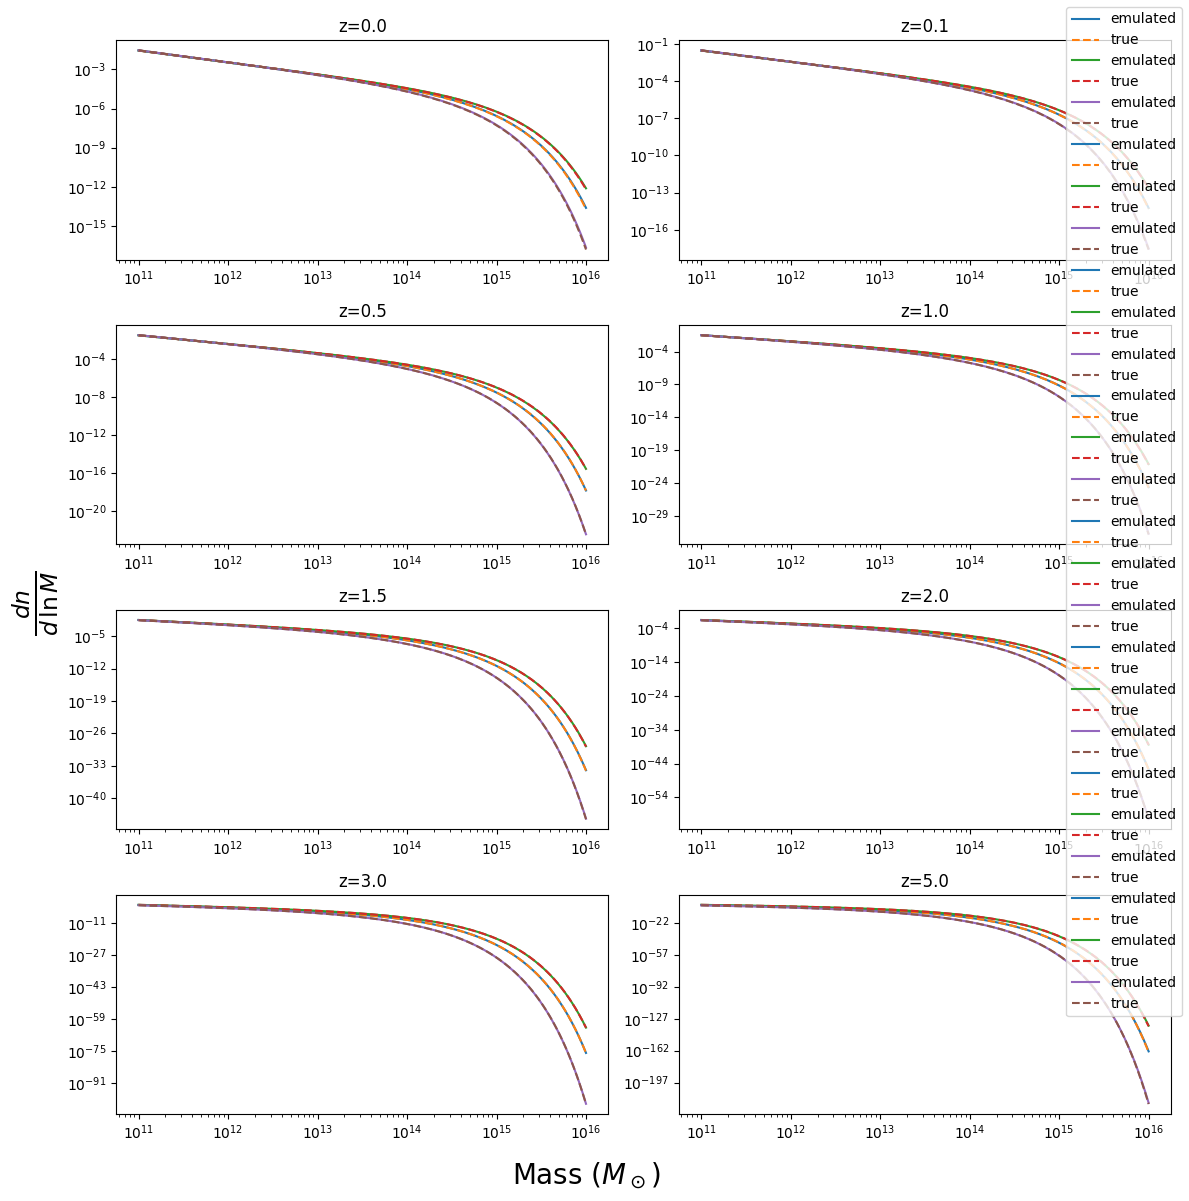

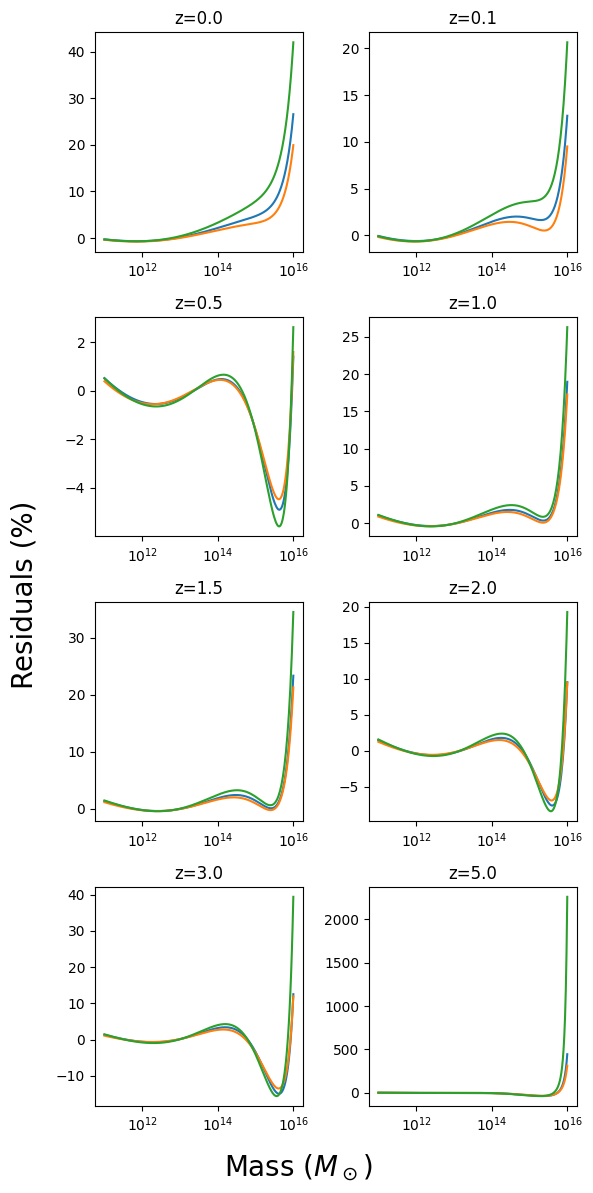

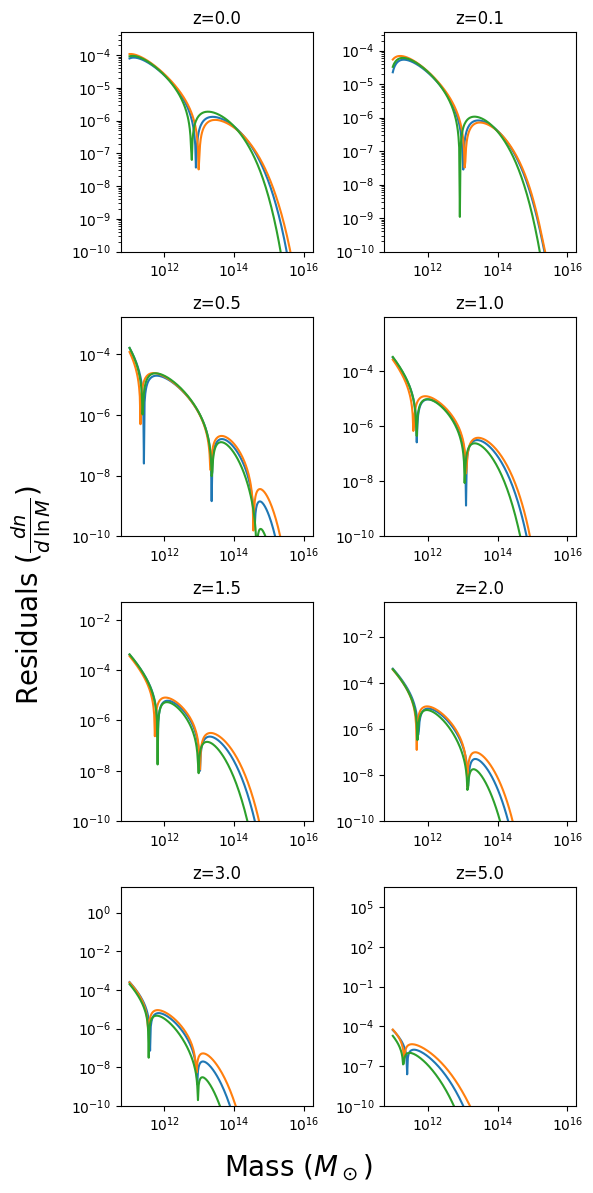

In [15]:
fig, ax = plt.subplots(4,2, figsize = (12,12))
x = ax.flatten()

for i in range(len(x)):
    for ii in range(len(cmgs)):
        x[i].plot(Ms, out3[i][ii], ls = "-", label = "emulated")
        x[i].plot(Ms, out2[i][ii], ls="--", label = "true")
    x[i].set_title(f"z={zs[i]}")
    x[i].set_yscale("log")
    x[i].set_xscale("log")

fig.supylabel(r"$\frac{dn}{d\,\ln{M}}$", fontsize = 24)
fig.supxlabel(r"Mass $(M_\odot)$", fontsize = 20)
fig.set_tight_layout(1)

fig2, ax2 = plt.subplots(4,2, figsize = (6,12))
x2 = ax2.flatten()

for i in range(len(x2)):
    for ii in range(len(cmgs)):
        x2[i].plot(Ms, (out3[i][ii]/out2[i][ii] - 1)*100, label = "")
    x2[i].set_title(f"z={zs[i]}")
    x2[i].set_yscale("linear")
    x2[i].set_xscale("log")

fig2.supylabel(r"Residuals (%)", fontsize = 20)
fig2.supxlabel(r"Mass $(M_\odot)$", fontsize = 20)
fig2.set_tight_layout(1)

fig3, ax3 = plt.subplots(4,2, figsize = (6,12))
x3 = ax3.flatten()

for i in range(len(x3)):
    for ii in range(len(cmgs)):
        x3[i].plot(Ms, jnp.abs(out3[i][ii]-out2[i][ii]), label = "")
    x3[i].set_title(f"z={zs[i]}")
    x3[i].set_yscale("log")
    x3[i].set_xscale("log")
    x3[i].set_ylim(bottom = 10**-10)

fig3.supylabel(r"Residuals ($\frac{dn}{d\,\ln{M}}$)", fontsize = 20)
fig3.supxlabel(r"Mass $(M_\odot)$", fontsize = 20)
fig3.set_tight_layout(1)
fig.legend()


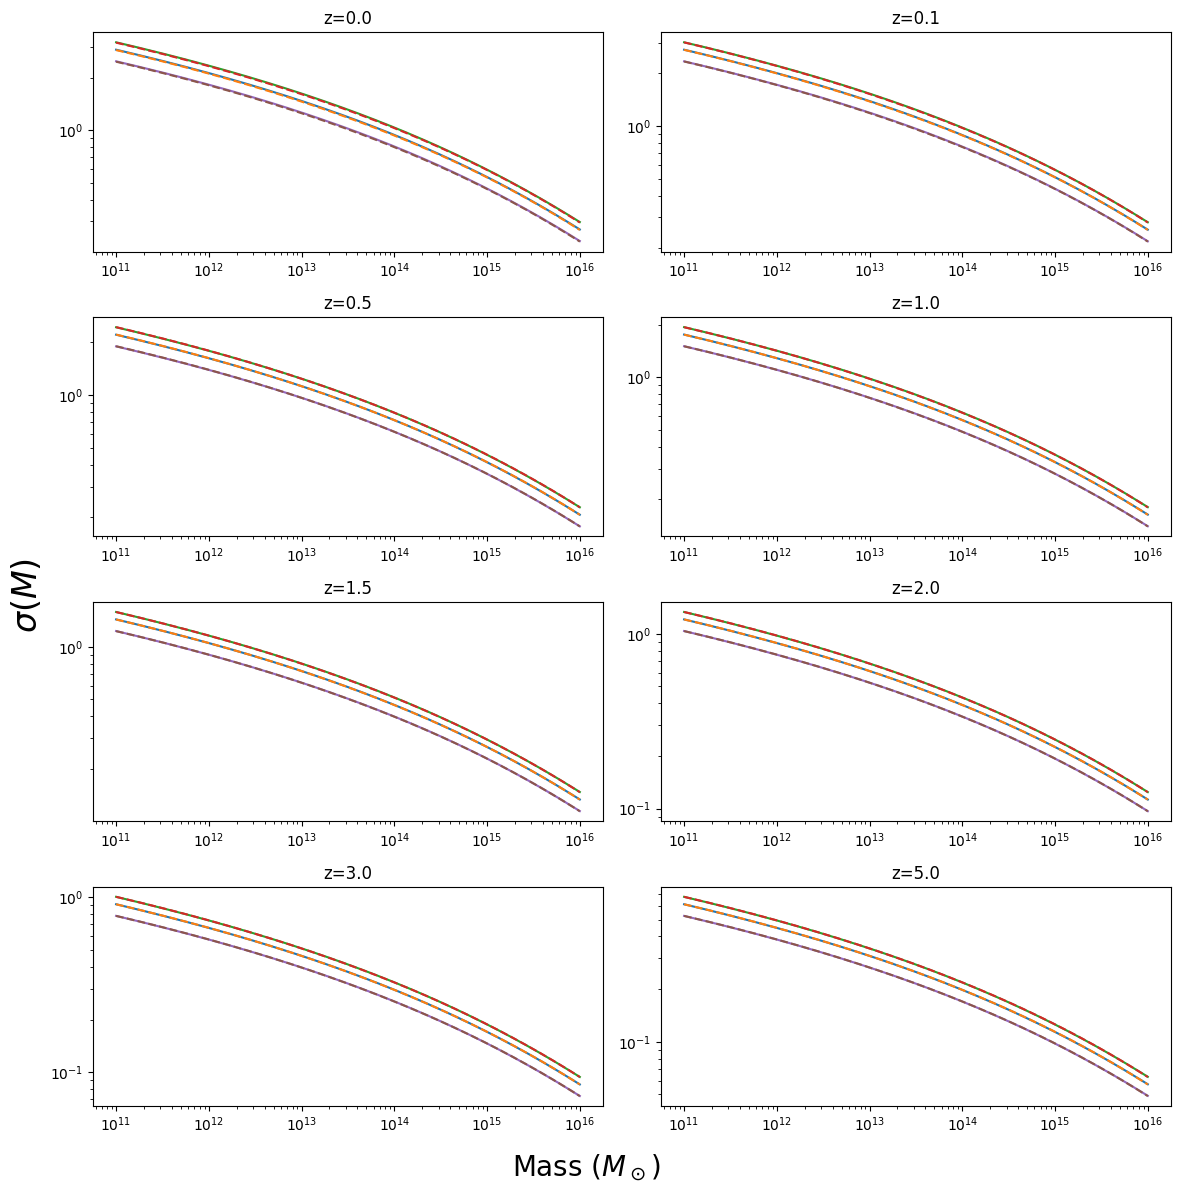

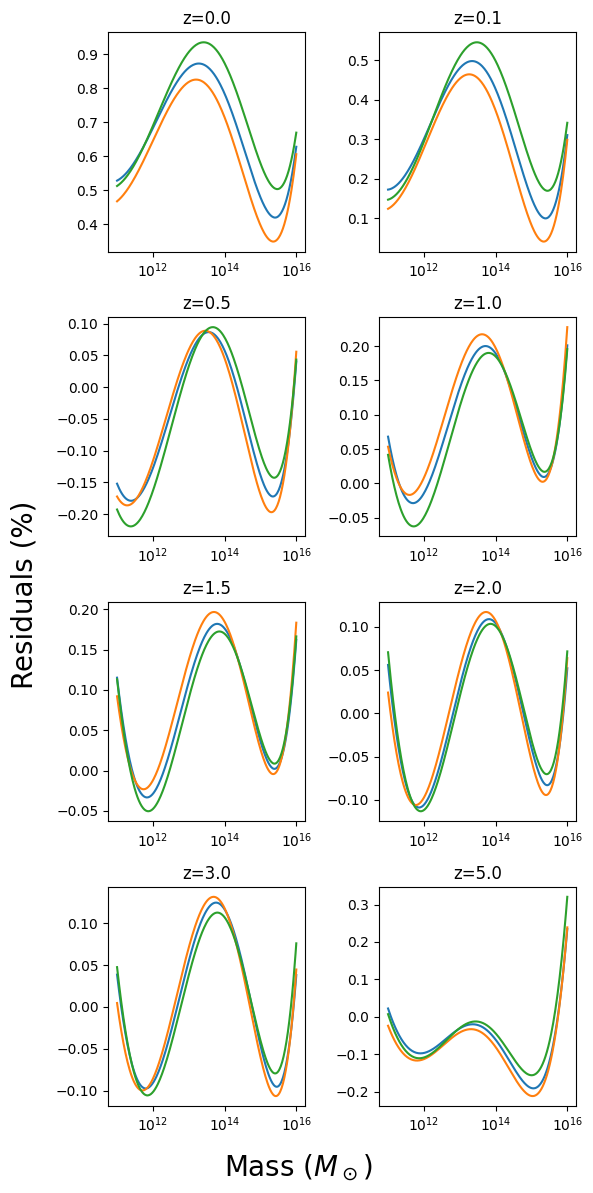

In [10]:
fig, ax = plt.subplots(4,2, figsize = (12,12))
x = ax.flatten()

for i in range(len(x)):
    for ii in range(len(cmgs)):
        x[i].plot(Ms, e_sig[i][ii], ls = "-", label = "emulated")
        x[i].plot(Ms, n_sig[i][ii], ls="--", label = "true")
    x[i].set_title(f"z={zs[i]}")
    x[i].set_yscale("log")
    x[i].set_xscale("log")

fig.supylabel(r"$\sigma(M)$", fontsize = 24)
fig.supxlabel(r"Mass $(M_\odot)$", fontsize = 20)
fig.set_tight_layout(1)

fig2, ax2 = plt.subplots(4,2, figsize = (6,12))
x2 = ax2.flatten()

for i in range(len(x2)):
    for ii in range(len(cmgs)):
        x2[i].plot(Ms, (e_sig[i][ii]/n_sig[i][ii] - 1)*100, label = "")
    x2[i].set_title(f"z={zs[i]}")
    x2[i].set_yscale("linear")
    x2[i].set_xscale("log")

fig2.supylabel(r"Residuals (%)", fontsize = 20)
fig2.supxlabel(r"Mass $(M_\odot)$", fontsize = 20)
fig2.set_tight_layout(1)